# CSE2530 Computational Intelligence
## Assignment 2: Artificial Neural Networks

<div style="background-color:#be3e3a">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
| Group            | X       |
|------------------|---------|
| Daniel Kolev     | 6160255 |
| Zain Qureshi     | 6143555 |
| Deyan Papazov    | 6191150 |
| Dragostin Ivanov | 6159737 |

</div>

#### Imports

In [77]:
# You may only use numpy to implement your neural network
# You are not allowed to use scikit-learn, other than for Section 1.6.
# You are also not allowed to use Pytorch, Tensorflow, and similar machine learning frameworks.
# You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.

# Put all of your imports in this code block
import numpy as np
import matplotlib.pyplot as plt

#### Loading the data

In [78]:
features = np.genfromtxt("../data/features.txt", delimiter=",")
targets = np.genfromtxt("../data/targets.txt", delimiter=",")
unknown = np.genfromtxt("../data/unknown.txt", delimiter=",")

## 1 Questions
### 1.2 Architecture
#### Question 1:

In [79]:
# Class of our Perceptron Model
class Perceptron:

    # Constructor of the class, initializes the weights and bias as well as the dimensions of the input data
    def __init__(self, dimensions):
        self.dimensions = dimensions
        self.w = np.random.rand(dimensions)
        self.b = np.random.rand()

    # Predict function, takes an input and returns the predicted class (0 or 1) based on the current weights and bias
    def predict(self, x):
        return np.where(np.dot(x, self.w) + self.b >= 0, 1, 0)

    # Train function, takes the training data, number of epochs, and learning rate as input and updates the weights and bias based on the loss calculated from the predictions
    def train(self, X, Y, epochs=1000, learning_rate=0.05):
        for i in range(epochs):
            for x, y in zip(X, Y):
                loss = y - self.predict(x)
                self.w = [ self.w[i] + learning_rate*x[i]*loss for i in range(self.dimensions) ]
                self.b = self.b + learning_rate*loss

In [80]:
# Function for computing the accuracy based on predictions and labels
def accuracy(labels, predicted):
    return np.mean(np.where(labels == predicted, 1, 0))

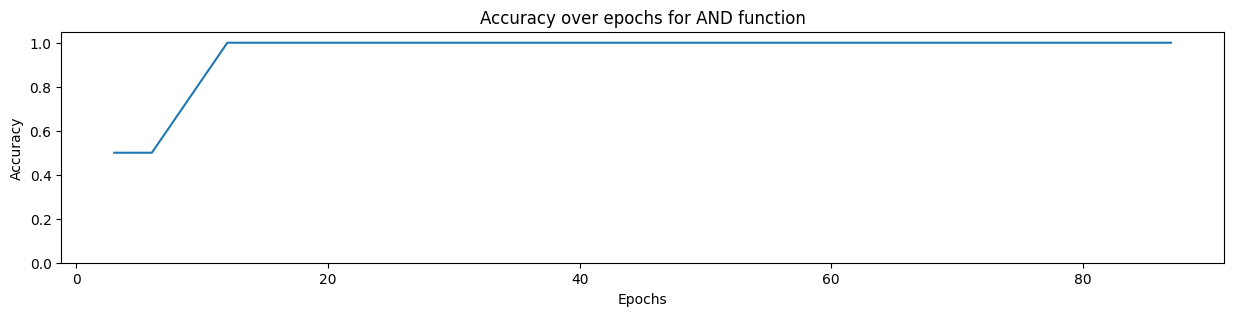

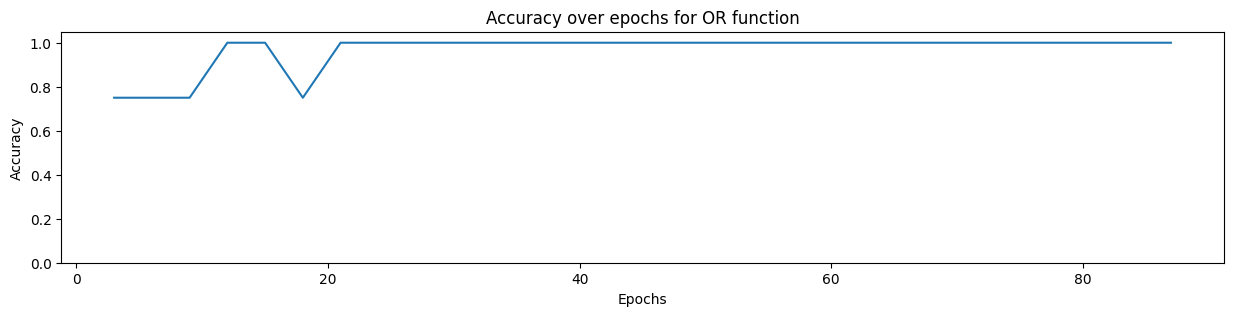

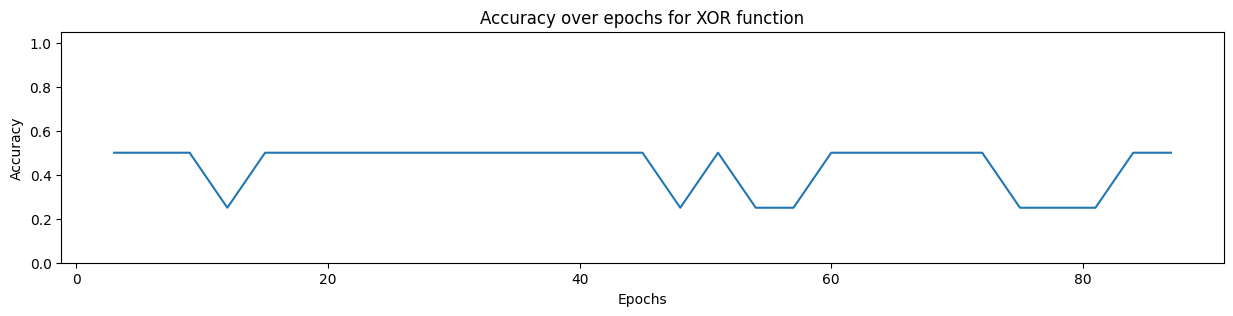

In [81]:
np.random.seed(1234)

# Define the input for the Perceptron tests that we are about to do
q1_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
q1_and_labels = np.array([0, 0, 0, 1])
q1_or_labels = np.array([0, 1, 1, 1])
q1_xor_labels = np.array([0, 1, 1, 0])

# Plotting function, makes the figures for the AND, OR, and XOR functions next to each other
def plot_error_over_epochs(X, Y, title="Accuracy over epochs"):
    epoch_numbers = [3 * i for i in range(1, 30)]
    accuracies = []
    for epoch_number in epoch_numbers:
        p = Perceptron(2)
        p.train(X, Y, epochs=epoch_number)
        accuracies.append(accuracy(p.predict(X), Y))

    plt.figure(figsize=(15, 3))
    plt.plot(epoch_numbers, accuracies)
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.title(title)
    plt.show()

plot_error_over_epochs(q1_train, q1_and_labels, title="Accuracy over epochs for AND function")
plot_error_over_epochs(q1_train, q1_or_labels, title="Accuracy over epochs for OR function")
plot_error_over_epochs(q1_train, q1_xor_labels, title="Accuracy over epochs for XOR function")

### The Perceptron
We have created a simple Perceptron class.
On initialisation, you must specify the dimensionality of the input data for the perceptron.
Using the `train` method you can train the perceptron on a given dataset X with labels Y. You can optionally specify the number of epochs and the learning rate.
Using the `predict` method you can use the trained perceptron on a dataset X to get the predicted labels.

We have also plotted the accuracy of the Perceptron over the number of training epochs for the AND, OR, and XOR operations. We can see that the Perceptron eventually (around epoch>20) learns the AND and OR operations, but it always fluctuates when it comes to the XOR operation.

This is because the AND and OR operations are linearly separable, where the XOR isn't. The Perceptron can only learn linear relationships and so it will never be able to learn the XOR operation.

#### Question 2

We will need 10 input neurons. This is because the input neurons equals the features of the input. We are given that we want to transform a 10 feature input so we will need 10 neurons. Each specific feature is mapped to a neuron.


#### Question 3

We will need 7 output neurons. This is because the number of output neurons is equal to the number of output classes to which we classify the input. In our case we want to classify the input into 1 out of 7 classes, so we need 7 output neurons.


#### Question 4

By the Universal Approximation Theorem 1 layer is enough for any classification task. This is a solid starting point because a single hidden layer can handle most basic classification tasks without making the math too complicated. We chose 16 neurons - comparable to the number of input features, which gives the model enough neurons to find patterns without overcomplicating things.

#### Question 5

Based on the fact that we will have one single class label as an output per sample, we would use the softmax function as the activation function for the output layer. The reason for this is that it gives mutually exclusive labels where it outputs probability scores for each class, and we would select the class with the highest probability.

For the hidden layers, we would use a ReLU. The vanishing gradient problem occurs when gradients become exponentially small during backpropagation due to repeated multiplication of derivatives less than 1. This prevents early layers from learning effectively, making deep networks difficult to train. Activation functions like sigmoid and tanh cause this because their derivatives are bounded below 1. ReLU mitigates this problem since its derivative is 1 for positive inputs, preventing gradient shrinkage.

#### Question 6

<img src="../Ci-6.jpg" width=500px>

### 1.3 Neural network implementation

In [82]:
# The Linear layer of our neural network, with the forward and backward functions
class Linear:

    # Constructor of the class, initializes the weights and bias as well as the dimensions of the input data, with different initialization strategies for the weights
    def __init__(self, in_features, out_features, init_strategy="zeros"):
        if init_strategy == "normal":
            mu, sigma = 0, 1
            self.weight = np.random.normal(mu, sigma, size=(in_features, out_features)) # (d,k)
        elif init_strategy == "xavier":
            mu, sigma = 0, np.sqrt(1/in_features)
            self.weight = np.random.normal(mu, sigma, size=(in_features, out_features))
        elif init_strategy == "he":
            mu, sigma = 0, np.sqrt(2/in_features)
            self.weight = np.random.normal(mu, sigma, size=(in_features, out_features))
        elif init_strategy == "uniform":
            self.weight = np.random.uniform(-0.1, 0.1, size=(in_features, out_features))
        else:
            self.weight = np.zeros(shape=(in_features, out_features))

        self.bias = np.zeros(out_features) # (k,)

        self.cache = None
        self.weight_grad = None
        self.bias_grad = None

    # Forward function, takes an input and returns the output of the linear layer based on the current weights and bias, also stores the input in the cache for use in the backward pass
    def forward(self, x):
        self.cache = x # (n,d)
        return x @ self.weight + self.bias # (n,d)(d,k) + (k,) = (n,k) + (n,k) broadcasted = (n,k)

    # Backward function, takes the upstream gradient as input and returns the gradient with respect to the input
    # Computes the gradients with respect to the weights and bias and stores them in the class variables
    def backward(self, dupstream):
        self.weight_grad = self.cache.T @ dupstream # (d,n)(n,k) = (d,k)
        self.bias_grad = np.sum(dupstream, axis=0) #(n,k) sum axis 0 = (k,)
        return dupstream @ self.weight.T # (n,k)(k,d) = (n,d)

In [83]:
# The Sigmoid activation function, which applies the sigmoid function to the input and also computes the derivative of the sigmoid function for use in backpropagation
class Sigmoid:

    # Applies the sigmoid function to the input
    def apply(self, x):
        return 1 / (1 + np.exp(-x))

    # Computes the derivative of the sigmoid function for use in backpropagation, based on the output of the sigmoid function
    def apply_derivative(self, x):
        return self.apply(x) * (1 - self.apply(x))

In [84]:
# The ReLU activation function, which applies the ReLU function to the input and also computes the derivative of the ReLU function for use in backpropagation
class ReLU:

    # Applies the ReLU function to the input
    def apply(self, x):
        return np.maximum(0, x)

    # Computes the derivative of the ReLU function for use in backpropagation, based on the input
    def apply_derivative(self, x):
        return np.where(x <= 0, 0, 1) # Derivative is 0 for x <= 0 and 1 for x > 0

In [85]:
# The Identity activation function, which does not change the input and also has a derivative of 1 for all inputs. We have added this activation function, because of the results from the toolbox's grid search. We need it to fulfill question 17.
class Identity:

    # Applies the identity function to the input
    def apply(self, x):
        return x

    # Computes the derivative of the identity function for use in backpropagation, which is 1 for all inputs
    def apply_derivative(self, x):
        return np.ones_like(x)

In [86]:
# The Activation class, which takes an activation function as input and applies it to the input in the forward pass, and also computes the gradient with respect to the input in the backward pass using the derivative of the activation function
class Activation:

    # Constructor of the class, takes an activation function as input and initializes the cache for storing the input for use in the backward pass
    def __init__(self, function):
        self.cache = None
        self.function = function

    # Forward function, takes an input and returns the output of the activation function based on the input, also stores the input in the cache for use in the backward pass
    def forward(self, x):
        self.cache = x #(n,k)
        return self.function.apply(x) #(n,k)

    # Backward function, takes the upstream gradient as input and returns the gradient with respect to the input
    def backward(self, dupstream):
        return dupstream * self.function.apply_derivative(self.cache) #(n,k) * C

In [87]:
# The Binary Cross Entropy Class, which computes the loss based on the predicted logits and the true labels, and also computes the gradient with respect to the logits for use in backpropagation
class BinaryCrossEntropy:

    # Computes the loss based on the predicted logits and the true labels, using the binary cross entropy formula, with numerical stability to avoid log(0)
    def value(self, labels, logits):
        eps = 1e-9  # numerical stability
        y = labels.reshape(-1, 1) # (n,1)
        return -np.mean(y * np.log(logits + eps) + (1 - y) * np.log(1 - logits + eps))

    # Computes the gradient with respect to the logits for use in backpropagation, based on the predicted logits and the true labels, with numerical stability to avoid dividing by zero
    def grad(self, labels, logits):
        eps = 1e-9
        y = labels.reshape(-1, 1) # (n,1)
        return (-y / (logits + eps) + (1 - y) / (1 - logits + eps)) / y.shape[0]

In [88]:
# The Softmax Cross Entropy loss class, which computes the loss based on the predicted logits and the true labels, and also computes the gradient with respect to the logits for use in backpropagation
class SoftmaxCrossEntropy:

    # Computes the softmax of the input logits, with numerical stability to avoid overflow
    def softmax(self, logits):
        # Stable softmax taken from the web
        shifted = logits - np.max(logits, axis=1, keepdims=True)
        exp = np.exp(shifted)
        return exp / np.sum(exp, axis=1, keepdims=True)

    # Computes the loss based on the predicted logits and the true labels, using the softmax cross entropy formula, with numerical stability to avoid division by zero
    def value(self, labels, logits):
        n = logits.shape[0]
        probs = self.softmax(logits)
        return -np.mean(np.log(probs[np.arange(n), labels]))

    # Computes the gradient with respect to the logits for use in backpropagation, based on the predicted logits and the true labels, with numerical stability to avoid division by zero
    def grad(self, labels, logits):
        n = logits.shape[0]
        probs = self.softmax(logits)
        probs[np.arange(n), labels] -= 1
        return probs / n


In [89]:
# The Network class, which takes a list of layers as input and applies them in sequence in the forward pass, and also applies the backward pass in reverse order to compute the gradients for all layers
class Network:
    def __init__(self, layers):
        self.layers = layers

    # Forward function, takes an input and applies all the layers in sequence to compute the output of the network
    def forward(self, x):
        logits = x
        for layer in self.layers:
            logits = layer.forward(logits)

        return logits

    # Backward function, takes the upstream gradient as input and applies the backward pass in reverse order to compute the gradients for all layers, returns the gradient with respect to the input
    def backward(self, dupstream):
        gradient = dupstream
        for layer in reversed(self.layers):
            gradient = layer.backward(gradient)
        return gradient

    # Optimizer step function, takes the learning rate as input and updates the weights and bias of all linear layers based on the gradients computed in the backward pass
    def optimizer_step(self, lr):
        for layer in self.layers:
            if isinstance(layer, Linear):
                layer.weight -= lr * layer.weight_grad
                layer.bias -= lr * layer.bias_grad


In [90]:
# Main training function, takes the network, training data and labels, validation data and labels,
# loss function, mapping function for logits to labels, learning rate, number of epochs, batch size, and early stopping parameters as input
# and trains the network while keeping track of the losses and accuracies over epochs
# Furthermore, if early stopping is enabled, it evaluates the validation loss at the end of each epoch and stops training
# if the validation loss does not improve for a certain number of epochs (patience) by at least a certain amount (min_delta)
def train(net,
          train_data, train_labels,
          val_data, val_labels,
          loss, mapToLabel, lr=0.1, epochs=1000,
          batch_size=None,
          early_stopping=False,
          patience=20,
          min_delta=0.001):

    losses = []
    accuracies = []
    n = train_data.shape[0]

    best_validation_loss = float('inf') # Initialize best validation loss to infinity for early stopping
    epochs_without_improvement = 0
    stopping_epoch = epochs

    for epoch in range(epochs):

        indices = np.random.permutation(n) # Shuffle the training data and labels at the beginning of each epoch to ensure that the batches are different in each epoch
        inputs_shuffled = train_data[indices]
        labels_shuffled = train_labels[indices]

        epoch_loss = 0

        # Normal case like before
        if batch_size is None:
            logits = net.forward(inputs_shuffled)
            loss_val = loss.value(labels_shuffled, logits)
            loss_grad = loss.grad(labels_shuffled, logits)

            net.backward(loss_grad)
            net.optimizer_step(lr)

            epoch_loss = loss_val

        else:
            for i in range(0, n, batch_size):
                X_batch = inputs_shuffled[i:i+batch_size]
                y_batch = labels_shuffled[i:i+batch_size]

                logits = net.forward(X_batch)
                loss_val = loss.value(y_batch, logits)
                loss_grad = loss.grad(y_batch, logits)

                net.backward(loss_grad)
                net.optimizer_step(lr)

                epoch_loss += loss_val * len(X_batch) # Multiply the loss by the batch size to get the total loss for the batch (since in our loss.value function we already average), which will be averaged later

            epoch_loss /= n

        logits_full = net.forward(train_data)
        acc = accuracy(train_labels, mapToLabel(logits_full))

        losses.append(epoch_loss)
        accuracies.append(acc)

        if early_stopping:
            logits_val = net.forward(val_data)
            loss_val_validation = loss.value(val_labels, logits_val)

            # Check if the validation loss has improved by at least min_delta
            # if so, update the best validation loss and reset the counter for epochs without improvement
            if loss_val_validation < best_validation_loss - min_delta:
                best_validation_loss = loss_val_validation
                epochs_without_improvement = 0
            else:
                # otherwise increment the counter
                epochs_without_improvement += 1

            # If the validation loss has not improved for a number of epochs equal to patience, stop training
            if epochs_without_improvement >= patience:
                stopping_epoch = epoch + 1
                break

    return losses, accuracies, stopping_epoch

### Data Preprocessing

We split our data into a training, validation and test set. We will use 70% of the data for training, 15% for validation and 15% for testing. We will use the training set to train our network, the validation set to tune our hyperparameters and the test set to evaluate our final model. The unknown set will be used to make predictions with our final model.

We will apply feature normalisation to the data. This is because it can help with the convergence of the network, and it can also help with the performance of the network. We will also transform the class labels to the range [0, 6] instead of [1, 7] because it is easier to work with zero indexed labels in the code.

In [91]:
np.random.seed(1234)

num_samples = features.shape[0]

labels = targets.astype(int) - 1

indices = np.arange(num_samples)

# Apply shuffle to features and targets
np.random.shuffle(indices)

features_shuffled = features[indices] # Transform labels to range [0, 6]
targets_shuffled = labels[indices]

train_end = int(0.7 * num_samples)
val_end = int(0.85 * num_samples)

X_train = features_shuffled[:train_end]
y_train = targets_shuffled[:train_end]

X_val = features_shuffled[train_end:val_end]
y_val = targets_shuffled[train_end:val_end]

X_test = features_shuffled[val_end:]
y_test = targets_shuffled[val_end:]

In [92]:
mean, std = np.mean(X_train, axis=0), np.std(X_train, axis=0) + 1e-9
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

In [93]:
# Plotting function for the losses and accuracies over epochs, takes the losses and accuracies as input and plots them side by side
def plot_accuracy_loss(losses, accuracies, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(20, 3))

    # Plotting losses
    axes[0].plot(losses, color="red")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")
    axes[0].set_ylim(0, max(losses) * 1.1)
    axes[0].set_title(title + "Loss over epochs")

    # Plotting accuracies
    axes[1].plot(accuracies, color="green")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1.1)
    axes[1].set_title(title + "Accuracy over epochs")
    plt.show()

### Training our Model

We will now finally train our model for a fixed neurons per layer - more specifically 7 neurons in order to see how the model performs.

#### Remarks:
- Initialization of Layers
    - He initialization is suitable for the RELU activation, because it helps to mitigate the vanishing gradient problem by keeping the variance of the activations and gradients relatively stable across layers. He initialization doubles the variance so it stays the same on each layer
    - Xavier initialization is also a good choice for the output layer, as it is designed to keep the variance of the activations and gradients stable across layers for both sigmoid and tanh activations, and it is also paired well with the softmax activation in the output layer.


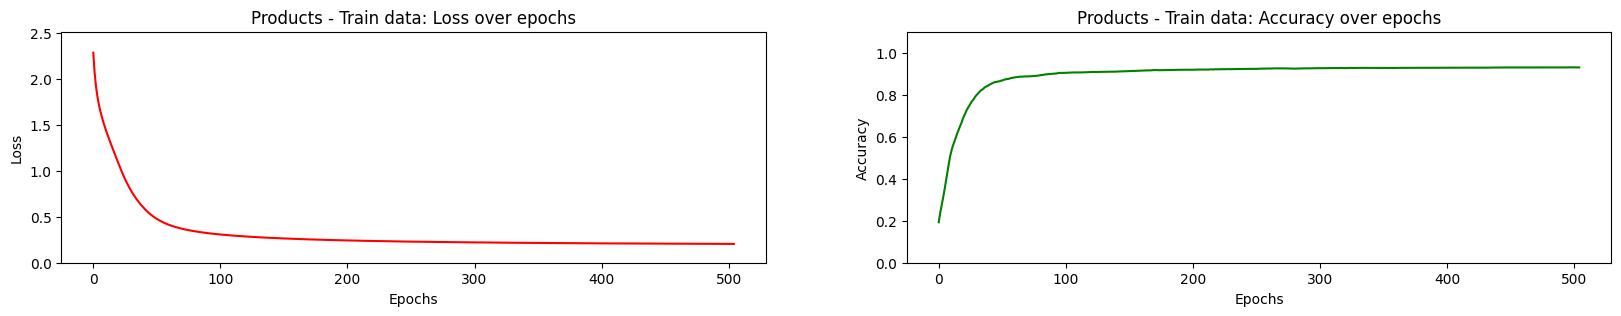

Final accuracy on train set: 0.9299617973440059
Final accuracy on validation set: 0.9363327674023769


In [94]:
np.random.seed(1234)

p = Network([Linear(10, 6, init_strategy="he"), Activation(ReLU()),
             Linear(6, 7, init_strategy="xavier")])

losses, accuracies, epochs = train(p,
                                   X_train, y_train,
                                   X_val, y_val,
                                   SoftmaxCrossEntropy(),
                                   lambda x: np.argmax(x, axis=1),
                                   lr=0.005,
                                   batch_size=64,
                                   early_stopping=True,
                                   epochs=1000)

plot_accuracy_loss(losses, accuracies, title="Products - Train data: ")
print("Final accuracy on train set:", accuracies[-1])

predicted_labels = np.argmax(p.forward(X_val), axis=1)

validation_accuracy = accuracy(y_val, predicted_labels)
print("Final accuracy on validation set:", validation_accuracy)

#### Question 7

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>
To obtain an unbiased estimate of the model's performance, we divide our dataset into three disjoint subsets - a training set(70%), a validation set (15%) and a test set(15%). The training set is used to train the network and learn the correct parameters, the validation set is used to tune hyperparameters such as the learning rate and number of epochs, and the test set for evaluating the final model performance.

Before splitting, we randomly shuffle the dataset using a randomly permuted index array. This shuffled index array is applied to both the features and the target labels. Random shuffling ensures that samples are distributed randomly across the training, validation and test sets preventing any ordering bias that could affect model evaluation.

Since the original dataset is balanced, with each class containing approximately the same number of samples, random shuffling preserves similar class proportions across all subsets. This ensures that the model is trained and evaluated on representative data, preventing bias toward any specific class and enabling reliable performance estimation.

To ensure reproducibility, the random number generator can be initialized with a fixed seed before shuffling. This guarantees that the same data split is produced every time the experiment is run, allowing consistent and reproducible results. We use this technique many times throughout the notebook.

#### Question 8

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>
We use accuracy on the validation set as the primary performence metric. This is beause of the nature of the task and it is easy to evaluate - if the predicted == real we have it correct. We chose multi class Cross-Entropy Loss for the optimization phase because it is mathematically coupled with the Softmax output layer. Unlike Mean Squared Error, Cross-Entropy heavily penalizes confident but wrong predictions, driving the network to learn faster and more robustly in multi-class classification tasks.

#### Question 9

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>
We have implemented early stopping in our train function which stops early when the loss does not decrease more than 20 times consecutively. By doing this we ensure that we stop training the model after we stop progressing. By actively monitoring a validation set, early stopping halts the training at the exact point where the model's ability to generalize stops improving, preventing overfitting and saving computational time.

#### Question 10

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

For each initialization strategy, we make 3 runs of our network. We find the average accuracy and the standard deviation of the accuracy at all points. Using this information and the help of generative AI, we create the plot that shows some interesting insights.

First, we can see that "He" initialization performs the best which is expected since it is known to work well for ReLU activation - the one we are using. The other best initialization is "Xavier" which is also expected since it pairs well with the Softmax activation in the outer layer.

Second, we can see that the uniform initialization has higher variance. That is because we have selected a large interval of selection - [-0.01, 0.01] and different runs may start from very different places.

Third, we can see that the zero initialization fails to learn. This is because the value and the gradient of ReLU at 0 is 0 and so nothing changes. Our network is always predicting label 0. And this is confirmed by the fact that about 14% of our target labels are from class 0. That is why the accuracy on zero initialization is always ~14%

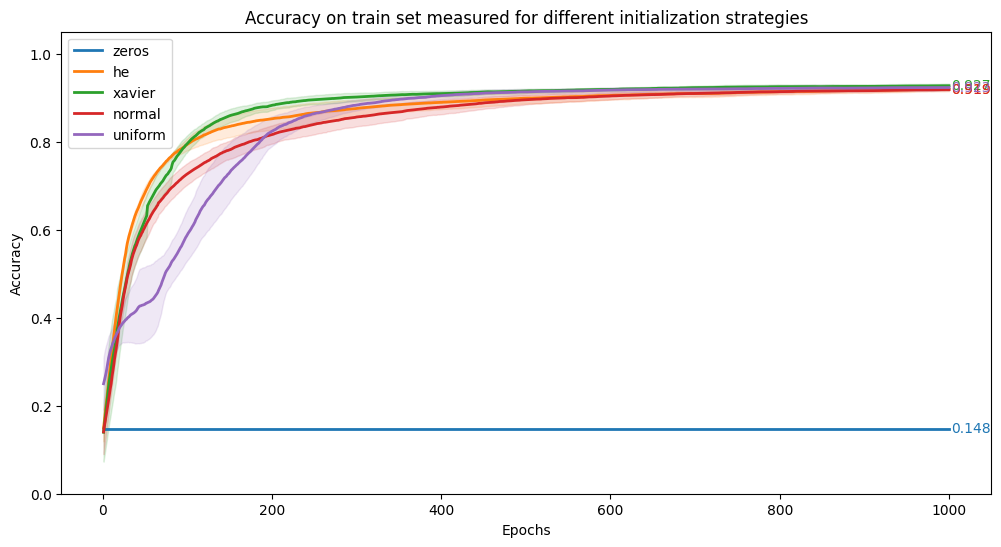

In [95]:
np.random.seed(1234)

init_strategies = ["zeros", "he", "xavier", "normal", "uniform"]
n_runs = 3
m_epochs = 1000

plt.figure(figsize=(12, 6))
colors = plt.get_cmap("tab10").colors

for i, strategy in enumerate(init_strategies):
    runs_acc = []
    for run in range(n_runs):
        p = Network([Linear(10, 6, init_strategy=strategy), Activation(ReLU()),
                     Linear(6, 7, init_strategy=strategy)])
        losses, accuracies, stop_epoch = train(p,
                                               X_train, y_train,
                                               X_val, y_val,
                                               SoftmaxCrossEntropy(),
                                               lambda x: np.argmax(x, axis=1),
                                               lr=0.1,
                                               epochs=m_epochs)
        runs_acc.append(accuracies)

    runs_acc = np.array(runs_acc)
    mean_acc = runs_acc.mean(axis=0)
    std_acc = runs_acc.std(axis=0)
    x = np.arange(1, m_epochs + 1)

    plt.plot(x, mean_acc, label=strategy, color=colors[i % len(colors)], linewidth=2)
    plt.fill_between(x, mean_acc - std_acc, mean_acc + std_acc, color=colors[i % len(colors)], alpha=0.15)

    plt.text(m_epochs + 2, mean_acc[-1], f"{mean_acc[-1]:.3f}", va="center", color=colors[i % len(colors)])

plt.title("Accuracy on train set measured for different initialization strategies")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.show()

In [96]:
# Showcase that the ratio of labels from class 0 is actually 0.14
print(np.mean(np.where(labels == 0, 1, 0)))

0.1424751718869366


### 1.4 Optimization

#### Question 11

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>
As the number of hidden neurons increases from 7 to 30, the average validation accuracy increases while the variance/ standard deviation decreases. However the increase from 7 to 13 and 19 neurons is much higher than the increase from 16 onward. We can see that the 7-neuron architecture is underfitting since the model can not learn the right parameters and therefore has 91%. The plateau at the end indicates that the network has reached its optimal capacity and adding more neurons does not increase the accuracy much, but makes the model more complex

In [97]:
np.random.seed(1234)

# Fix a network with 1 layer
# Each layer will have a number of neurons in the range [7, 30]
neurons = [7, 13, 19, 25, 30]
neurons_to_average_acc = []
num_iter = 10
std_performances = []

for neuron_count in neurons:

    accuracies_for_setup = []
    for _ in range(num_iter):

        p = Network([Linear(10, neuron_count, init_strategy="he"), Activation(ReLU()),
                     Linear(neuron_count, 7, init_strategy="xavier")])

        train(p,
                X_train, y_train,
                X_val, y_val,
                SoftmaxCrossEntropy(),
                lambda x: np.argmax(x, axis=1),
                lr=0.1,
                epochs=500)

        predicted_labels = np.argmax( p.forward(X_val), axis=1)
        accuracies_for_setup.append(accuracy(y_val, predicted_labels))

    neurons_to_average_acc.append(np.mean(accuracies_for_setup))
    std_performances.append(np.std(accuracies_for_setup))


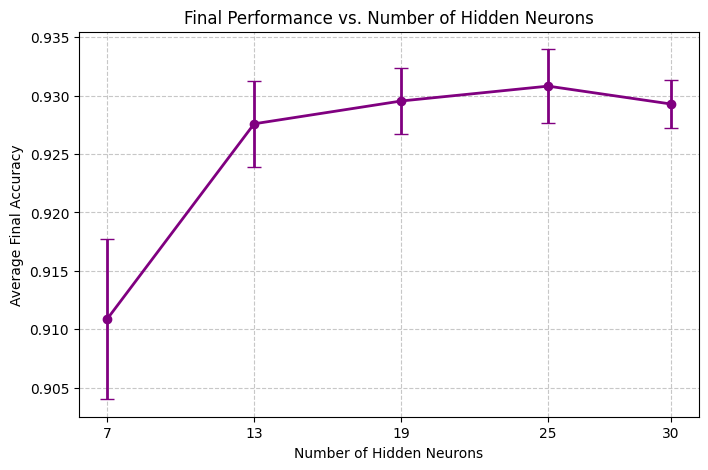

In [98]:
plt.figure(figsize=(8, 5))

plt.errorbar(neurons, neurons_to_average_acc, yerr=std_performances,
             marker='o', capsize=5, linestyle='-', color='purple', linewidth=2)

plt.title("Final Performance vs. Number of Hidden Neurons")
plt.xlabel("Number of Hidden Neurons")
plt.ylabel("Average Final Accuracy")
plt.xticks(neurons)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Question 12

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>
We first create a modified train function, that also keeps track of the model performance on the validation and test set across epochs.

According to the graph above the best performing number of neurons is 25. However, this choice is debatable because the difference in accuracy is only ~2% which is neglectable, but the risk of overfitting is much greater. Later, we will discuss this further and make a better choice, but for this question we pick the setup with 25 neurons to conform to the results of the plot above.

In [99]:
# To fulfill Q12, we need to modify our train function to also keep track of the model performance on the val and test set across epochs.

def train_with_extended_history(net,
                                train_data, train_labels,
                                val_data, val_labels,
                                test_data, test_labels,
                                loss, mapToLabel, lr=0.1, epochs=1000,
                                batch_size=None,
                                early_stopping=False,
                                patience=20,
                                min_delta=0.001):

    losses, losses_val, losses_test = [], [], []
    accuracies, accuracies_val, accuracies_test = [], [], []
    n = train_data.shape[0]

    best_validation_loss = float('inf')
    epochs_without_improvement = 0
    stopping_epoch = epochs

    for epoch in range(epochs):

        indices = np.random.permutation(n)
        inputs_shuffled = train_data[indices]
        labels_shuffled = train_labels[indices]

        epoch_loss = 0

        # Normal case like before
        if batch_size is None:
            logits = net.forward(inputs_shuffled)
            loss_val = loss.value(labels_shuffled, logits)
            loss_grad = loss.grad(labels_shuffled, logits)

            net.backward(loss_grad)
            net.optimizer_step(lr)

            epoch_loss = loss_val

        else:
            for i in range(0, n, batch_size):
                X_batch = inputs_shuffled[i:i+batch_size]
                y_batch = labels_shuffled[i:i+batch_size]

                logits = net.forward(X_batch)
                loss_val = loss.value(y_batch, logits)
                loss_grad = loss.grad(y_batch, logits)

                net.backward(loss_grad)
                net.optimizer_step(lr)

                epoch_loss += loss_val * len(X_batch)

            epoch_loss /= n

        logits_full = net.forward(train_data)
        acc = accuracy(train_labels, mapToLabel(logits_full))
        losses.append(epoch_loss)
        accuracies.append(acc)

        logits_val = net.forward(val_data)
        loss_val_validation = loss.value(val_labels, logits_val)
        acc_val = accuracy(val_labels, mapToLabel(logits_val))
        losses_val.append(loss_val_validation)
        accuracies_val.append(acc_val)

        logits_test = net.forward(test_data)
        loss_val_test = loss.value(test_labels, logits_test)
        acc_test = accuracy(test_labels, mapToLabel(logits_test))
        losses_test.append(loss_val_test)
        accuracies_test.append(acc_test)

        if early_stopping:
            logits_val = net.forward(val_data)
            loss_val_validation = loss.value(val_labels, logits_val)

            if loss_val_validation < best_validation_loss - min_delta:
                best_validation_loss = loss_val_validation
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                stopping_epoch = epoch + 1
                break

    return losses, accuracies, losses_val, accuracies_val, losses_test, accuracies_test, stopping_epoch

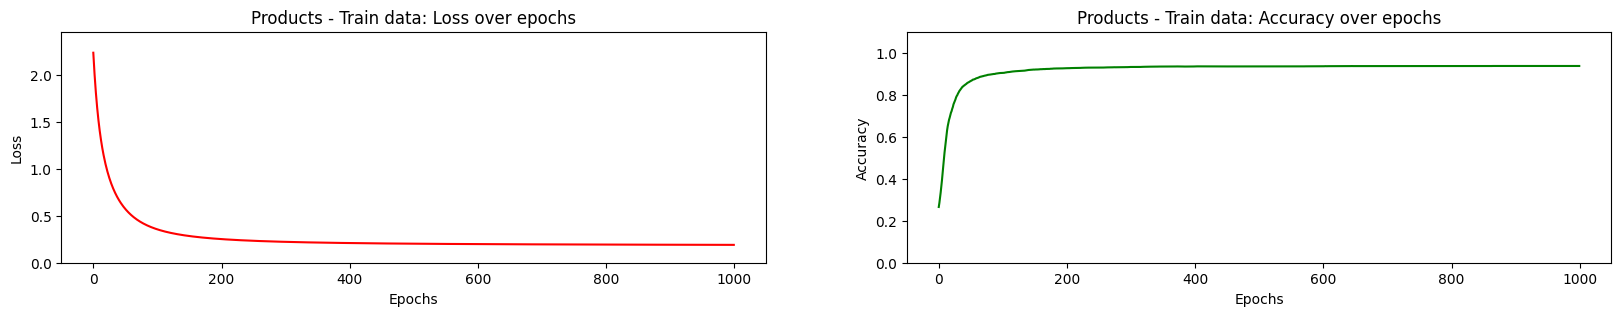

Final accuracy on train set: 0.9368746589048572


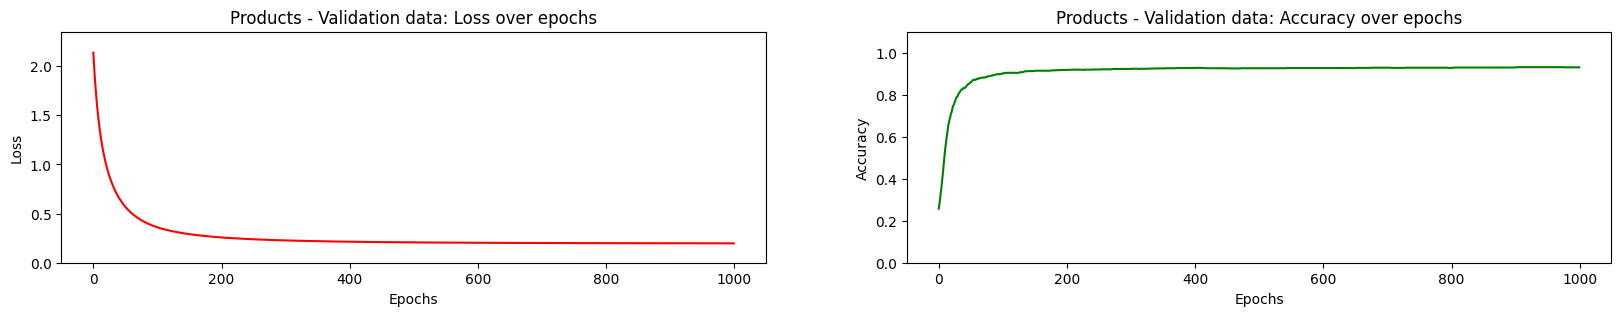

Final accuracy on validation set: 0.9303904923599321


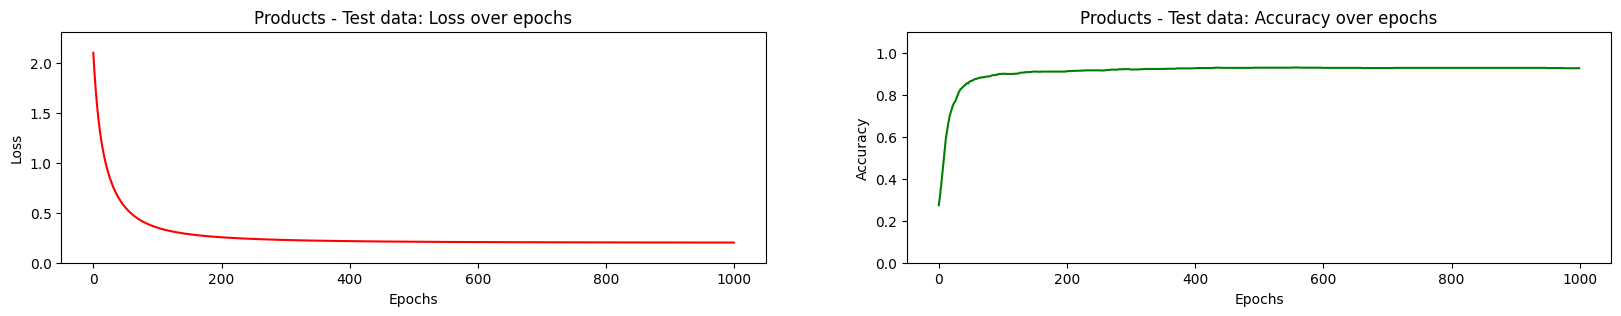

Final accuracy on test set: 0.926208651399491


In [100]:
np.random.seed(1234)

p = Network([Linear(10, 25, init_strategy="he"), Activation(ReLU()),
                     Linear(25, 7, init_strategy="xavier")])

losses, accuracies, losses_val, accuracies_val, losses_test, accuracies_test, epochs = train_with_extended_history(p,
                                   X_train, y_train,
                                   X_val, y_val,
                                   X_test, y_test,
                                   SoftmaxCrossEntropy(),
                                   lambda x: np.argmax(x, axis=1),
                                   lr=0.1,
                                   epochs=1000)

plot_accuracy_loss(losses, accuracies, title="Products - Train data: ")
print("Final accuracy on train set:", accuracies[-1])
plot_accuracy_loss(losses_val, accuracies_val, title="Products - Validation data: ")
print("Final accuracy on validation set:", accuracies_val[-1])
plot_accuracy_loss(losses_test, accuracies_test, title="Products - Test data: ")
print("Final accuracy on test set:", accuracies_test[-1])

### 1.5 Evaluation

#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

The results are very comparable, but obviously we can see that the accuracy on the train set is higher than the other two. That is because the model is trained on the train set, and effectively it has been given information about their true labels. This allows us to fit our model according to patterns identified within the train data and see how well it generalises over unseen data.

Then the accuracy on the validation set is also higher than the test set. That is because we have used the validation set to tune our hyperparameters and to do early stopping, so we have indirectly given the model some information about the validation set as well. The test set is completely unseen and therefore has the lowest accuracy.

However, the fact that the accuracies are close to each other is a good sign that our model is generalizing well.

In [101]:
print("Final accuracy on train set:", accuracies[-1])
print("Final accuracy on validation set:", accuracies_val[-1])
print("Final accuracy on test set:", accuracies_test[-1])

Final accuracy on train set: 0.9368746589048572
Final accuracy on validation set: 0.9303904923599321
Final accuracy on test set: 0.926208651399491


#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

With the help of Sci-kit learn as shown in the Toolbox, we plot the confusion matrix. We see that our model is significantly better at recognizing objects from classes 4 and 6 and significantly worse at recognizing objects from classes 3 and 7.

Based on this, we can say that the performance of our network is identical to its worst performance for a specific class and that is ~89% which we then still think is fairly good performance.

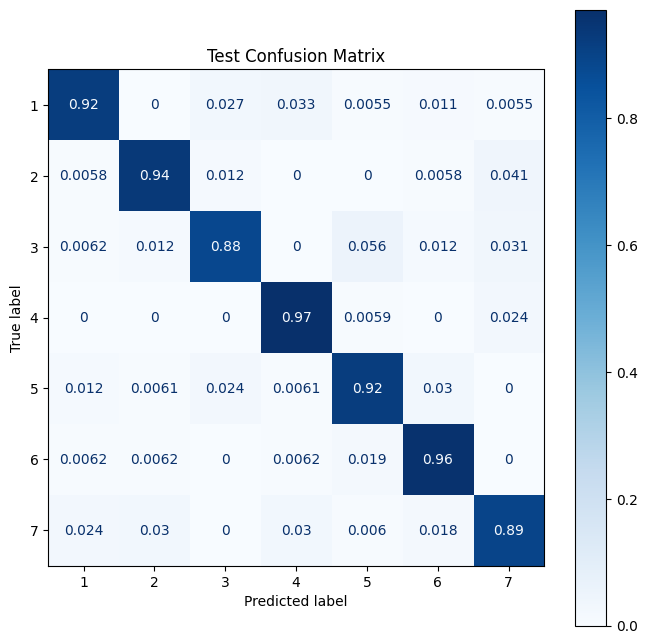

In [102]:
from sklearn.metrics import ConfusionMatrixDisplay

figure = plt.figure(figsize=(8,8))
ax = figure.add_subplot()
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    np.argmax(p.forward(X_test), axis=1),
    display_labels=np.arange(1, 8),
    cmap=plt.cm.Blues,
    normalize="true",
    ax=ax
)
disp.ax_.set_title("Test Confusion Matrix")
plt.show()

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

### 1.6 Scikit-learn

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

We downloaded the Toolbox notebook and added a wide selection of configuration options that our network implementation supports. After running the script for 11 minutes, this is the resulting report from Sci-kit learn grid search:

```python
Grid search on grid:
-hidden_layer_sizes: [[4], [8], [16], [4, 4], [8, 4]]
-activation: ['relu', 'identity', 'tanh', 'logistic']
-learning_rate_init: [0.005, 0.01, 0.05, 0.1]
-max_iter: [200, 500, 1000]
-batch_size: [32, 64, 128]
-validation_fraction: [0.12749999999999997]
-early_stopping: [True]
-n_iter_no_change: [10]
-tol: [0.0001]
-random_state: [42]

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Best parameters found by grid search:
-activation: identity
-batch_size: 64
-early_stopping: True
-hidden_layer_sizes: [8]
-learning_rate_init: 0.005
-max_iter: 200
-n_iter_no_change: 10
-random_state: 42
-tol: 0.0001
-validation_fraction: 0.12749999999999997
```

Using these parameters the toolbox achieves an accuracy of 93% which is slightly better than our model.
The chosen parameters differ significantly from our choices.

First, we did not even consider the identity activation function before. This is a very interesting choice from the grid search, because it means that the best performing network is actually a linear model without any non-linearity.

Second, the grid search chose a smaller neuron count than we did. This is interesting because it means that the model with 8 neurons in the hidden layer performs better than the model with 25 neurons that we chose based on our previous experiments. This probably means that our model overfits to the data, whereas the toolbox model generalizes better.

Third, the grid search also chose to make use of the additional functionalities in our network such as the batch_size and the early stopping, which we did not use in our previous experiments. This shows the importance of tuning all the hyperparameters and making use of all the functionalities that our network implementation offers.




#### Question 17

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

</div>

This model performs neglectably better, but the fascinating part is that it does not introduce any non-linearity and still achieves 93% accuracy on the test set. The speed of convergence is significantly faster because of the batch_size and early_stopping and the model is much simpler which must mean that it generalizes better to unseen data.

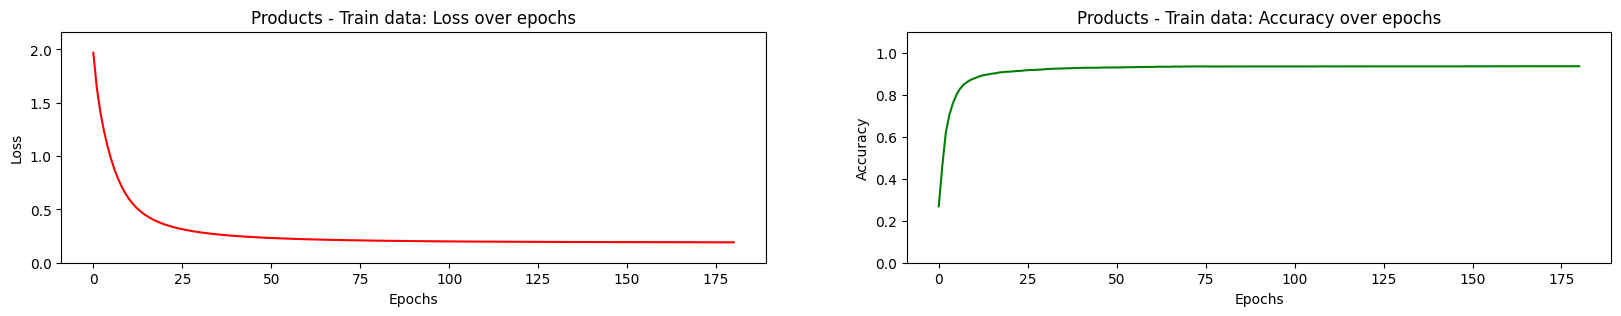

Final accuracy on train set: 0.9356012370383846
Final accuracy on validation set: 0.9380305602716469
Final accuracy on test set: 0.9287531806615776


In [103]:
np.random.seed(1234)

p = Network([Linear(10, 8, init_strategy="xavier"), Activation(Identity()),
             Linear(8, 7, init_strategy="xavier")])

losses, accuracies, epochs = train(p,
                                   X_train, y_train,
                                   X_val, y_val,
                                   SoftmaxCrossEntropy(),
                                   lambda x: np.argmax(x, axis=1),
                                   lr=0.005,
                                   batch_size=64,
                                   early_stopping=True,
                                   epochs=200)

plot_accuracy_loss(losses, accuracies, title="Products - Train data: ")
print("Final accuracy on train set:", accuracies[-1])

predicted_labels = np.argmax(p.forward(X_val), axis=1)

validation_accuracy = accuracy(y_val, predicted_labels)
print("Final accuracy on validation set:", validation_accuracy)

test_accuracy = accuracy(y_test, np.argmax(p.forward(X_test), axis=1))
print("Final accuracy on test set:", test_accuracy)

### 1.7 Reflection

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

</div>

In [104]:
# Cells for Autograder final predictions
np.random.seed(1234)

p_final = Network([Linear(10, 6, init_strategy="he"), Activation(ReLU()),
             Linear(6, 7, init_strategy="xavier")])

# Normalize unknown data
unknown_normalized = (unknown - mean) / std

train(p_final,
       X_train, y_train,
       X_val, y_val,
       SoftmaxCrossEntropy(),
       lambda x: np.argmax(x, axis=1),
       lr=0.005,
       batch_size=64,
       early_stopping=True,
       epochs=1000)

print("Accuracy on the test set:", accuracy(y_test, np.argmax(p_final.forward(X_test), axis=1)))

final_predictions = np.argmax(p_final.forward(unknown_normalized), axis=1) + 1

Accuracy on the test set: 0.926208651399491


In [105]:
toolbox_predictions = np.loadtxt("Group_00_classes.txt", delimiter=",")
print(np.mean(final_predictions == toolbox_predictions))

0.9681122448979592


### 1.8 Pen and paper

#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

</div>

<img src="../Ci-20_21.jpeg">

### 1.9 Division of work

#### Question 22

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

</div>

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**

</div>